In [1]:
import spikeinterface.full as si
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
# FORMAT
FORMAT = 'mcs'   # 'spikeglx' | 'openephys' | 'mcs'

# PATHS
spikeglx_folder  = Path(r'C:\Users\labuser\Ilaria\Project\small_rec\2142_g0\2142_g0_imec0')
openephys_folder = Path(r'C:\Users\labuser\Downloads\data for Ilaria\data for Ilaria\2023_09_13\2023-09-13_12-40-06_W3P12_first_piece_Pos2')
mcs_file         = Path(r'C:\Users\labuser\Ilaria\C5\C5_output\2026-03-27T11-17-48McsRecording_E-00218.h5')

if FORMAT == 'spikeglx':
    base_folder = Path(r'C:\Users\labuser\Ilaria\Project\processed\2142_output')
elif FORMAT == 'openephys':
    base_folder = Path(r'C:\Users\labuser\ilaria\Project\processed\openephys_output_2min')
elif FORMAT == 'mcs':
    base_folder = Path(r'C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min')
else:
    raise ValueError(f"Unknown FORMAT '{FORMAT}'. Choose 'spikeglx', 'openephys', or 'mcs'.")

base_folder.mkdir(parents=True, exist_ok=True)


In [3]:
# FORMAT-SPECIFIC PARAMETERS

if FORMAT == 'mcs':
    use_raw  = False       # False -> .h5 (Multi Channel DataManager export); True -> .raw binary
    freq_min = 200.         # highpass cutoff (Hz)
        
    sorter   = 'herdingspikes'   # 'herdingspikes' | 'tridesclous2' | 'spykingcircus2' | 'mountainsort5' | 'kilosort4'
    cref_operator  = 'median'
    cref_reference = 'local'
    _analyzer_sparse = False
    _source_path = str(mcs_file)

elif FORMAT == 'openephys':
    stream_name = 'Record Node 101#Acquisition_Board-100.Rhythm Data'
    # run this to list available streams:
    # print(si.get_neo_streams('openephysbinary', openephys_folder))
    freq_min = 300.         
    sorter   = 'tridesclous2'      # 'herdingspikes' | 'tridesclous2' | 'spykingcircus2' | 'mountainsort5' | 'kilosort4'
    cref_operator  = 'median'
    cref_reference = 'global'
    _analyzer_sparse = False
    _source_path = str(openephys_folder)
    # TTL-triggered artifact removal (disabled by default, uncomment to use)
    # use_ttl_artifacts = False
    # ttl_channel_id    = 'Rhythm FPGA TTL Input'

elif FORMAT == 'spikeglx':
    stream_name = 'imec0.ap'
    freq_min = 400.          
    sorter   = 'kilosort4'        # 'herdingspikes' | 'tridesclous2' | 'spykingcircus2' | 'mountainsort5' | 'kilosort4'
    cref_operator  = 'median'
    cref_reference = 'global'
    _analyzer_sparse = True
    _source_path = str(spikeglx_folder)

# PROBE MAP
# Option A: fill in manual_probe_map directly, e.g.:
#   manual_probe_map = {'0': (0, 0), '1': (200, 0), '2': (400, 0), ...}
#   keys must be channel ids as strings, values are (x, y) in micrometers.
# Option B: point to a CSV with columns channel_id,x,y and leave manual_probe_map as None.
# If both are None, a dummy fallback probe is used (see PROBE SETUP cell).
manual_probe_map = None
manual_probe_csv = None

# COMMON PARAMETERS
job_kwargs = dict(n_jobs=4, chunk_duration='1s', progress_bar=True)

# Artifact removal (disabled by default — uncomment in the PREPROCESSING cell to use)
# artifact_timestamps_s = []
# artifact_ms_before    = 2.0
# artifact_ms_after     = 5.0

# WAVEFORM EXTRACTION
waveform_ms_before  = 1.5
waveform_ms_after   = 2.0
max_spikes_per_unit = 500

# QUALITY METRICS
metric_names = [
    'num_spikes', 'firing_rate', 'presence_ratio', 'snr',
    'isi_violation', 'rp_violation', 'sliding_rp_violation',
    'synchrony', 'firing_range',
    'amplitude_cutoff', 'amplitude_median', 'amplitude_cv',
    'drift',
]

#Set on False if you want to run the code faster
compute_pca_metrics = True
pca_metric_names = ['mahalanobis', 'd_prime', 'nearest_neighbor', 'silhouette']
pca_n_components = 5
pca_mode          = 'by_channel_local'
if compute_pca_metrics:
    metric_names = metric_names + pca_metric_names

metric_extension_params = {
    'presence_ratio': {'bin_duration_s': 60},
    'drift':          {'interval_s': 60, 'min_spikes_per_interval': 100},
}

# QUALITY FILTERING
amplitude_cutoff_thresh     = 0.1
isi_violations_ratio_thresh = 1
presence_ratio_thresh       = 0.9


In [4]:
# LOAD
if FORMAT == 'mcs':
    raw_rec = si.read_mcsraw(mcs_file) if use_raw else si.read_mcsh5(mcs_file)
elif FORMAT == 'openephys':
    raw_rec = si.read_openephys(openephys_folder, stream_name=stream_name, load_sync_channel=False,
                                block_index=0)
elif FORMAT == 'spikeglx':
    raw_rec = si.read_spikeglx(spikeglx_folder, stream_name=stream_name, load_sync_channel=False)

print(raw_rec)

#diagnostic

print("Number of channels:", raw_rec.get_num_channels())
print("Channel ids:", list(raw_rec.channel_ids))
try:
    raw_rec.get_probe()
    print("Probe geometry: PRESENT in file")
except ValueError:
    print("Probe geometry: NOT present in file")


MCSH5RecordingExtractor: 60 channels - 25000.000000 Hz - 1 segments - 4,860,000 samples 
                         194.40s (3.24 minutes) - int32 dtype - 1.09 GiB
  file_path: C:\Users\labuser\Ilaria\C5\C5_output\2026-03-27T11-17-48McsRecording_E-00218.h5
Number of channels: 60
Channel ids: ['Ch0', 'Ch1', 'Ch2', 'Ch3', 'Ch4', 'Ch5', 'Ch6', 'Ch7', 'Ch8', 'Ch9', 'Ch10', 'Ch11', 'Ch12', 'Ch13', 'Ch14', 'Ch15', 'Ch16', 'Ch17', 'Ch18', 'Ch19', 'Ch20', 'Ch21', 'Ch22', 'Ch23', 'Ch24', 'Ch25', 'Ch26', 'Ch27', 'Ch28', 'Ch29', 'Ch30', 'Ch31', 'Ch32', 'Ch33', 'Ch34', 'Ch35', 'Ch36', 'Ch37', 'Ch38', 'Ch39', 'Ch40', 'Ch41', 'Ch42', 'Ch43', 'Ch44', 'Ch45', 'Ch46', 'Ch47', 'Ch48', 'Ch49', 'Ch50', 'Ch51', 'Ch52', 'Ch53', 'Ch54', 'Ch55', 'Ch56', 'Ch57', 'Ch58', 'Ch59']
Probe geometry: NOT present in file


[probe] Step 1: no geometry found in the file.
[probe] No manual map provided (manual_probe_map / manual_probe_csv are both None).
[probe] Using a dummy probe (fallback). All 60 channels are spaced 3000 um apart so the sorter treats them as spatially independent. This is NOT real geometry, provide manual_probe_map or manual_probe_csv for proper results.


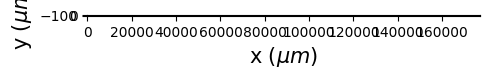

In [5]:
# PROBE SETUP
#
#   1) Geometry already in the file        -> use it as-is, nothing to do.
#   2) Manual map provided                 -> use the (x, y) positions typed in,
#                                             or that is loaded from a CSV file.
#   3) Nothing available                   -> fall back to a "dummy" probe where every
#                                             channel is placed very far from the others.
#
# IMPORTANT: option 3 is a safety net, not a real fix. If data ends up using the
# dummy probe, sorting quality will likely suffer for anything that relies on spatial
# information. Use option 2 whenever the real layout is known.

from probeinterface import Probe

n_ch = raw_rec.get_num_channels()

_original_channel_ids = raw_rec.channel_ids.copy()

# STEP 1: geometry already in the file
_has_geometry = False
try:
    raw_rec.get_probe()
    _has_geometry = True
    print(f"[probe] Geometry already in the file ({n_ch} channels).")
except ValueError:
    print("[probe] Step 1: no geometry found in the file.")

#  STEP 2: manual map provided
if not _has_geometry:
    _positions = None

    if manual_probe_csv is not None:
        # CSV must have columns: channel_id, x, y
        import csv
        _positions = {}
        with open(manual_probe_csv) as _f:
            for _row in csv.DictReader(_f):
                _positions[str(_row['channel_id'])] = (float(_row['x']), float(_row['y']))
        print(f"[probe] Loaded {len(_positions)} channel positions from CSV -> {manual_probe_csv}")

    elif manual_probe_map is not None:
        _positions = manual_probe_map
        print(f"[probe] Using {len(_positions)} manually specified channel positions.")

    if _positions is not None:
        
        _missing = [c for c in raw_rec.channel_ids if str(c) not in _positions]
        if _missing:
            raise ValueError(
                f"manual_probe_map / manual_probe_csv is missing positions for channels: {_missing}. "
                f"Add them, or remove manual_probe_map/csv to fall back to the dummy probe."
            )
        _ordered_xy = np.array([_positions[str(c)] for c in raw_rec.channel_ids], dtype=float)

        probe = Probe(ndim=2, si_units='um')
        probe.set_contacts(positions=_ordered_xy, shapes='circle', shape_params={'radius': 7.5})
        probe.create_auto_shape(probe_type='tip')
        probe.set_device_channel_indices(np.arange(n_ch))
        raw_rec = raw_rec.set_probe(probe, group_mode='by_probe')
        raw_rec = raw_rec.rename_channels(_original_channel_ids)  # restore original ids
        _has_geometry = True
        print(f"[probe] Manual map attached ({n_ch} channels).")
    else:
        print("[probe] No manual map provided (manual_probe_map / manual_probe_csv are both None).")

# STEP 3: fallback dummy probe
if not _has_geometry:
    _dummy_spacing_um = 3000. 
    probe = Probe(ndim=2, si_units='um')
    probe.set_contacts(
        positions=np.column_stack([np.arange(n_ch, dtype=float) * _dummy_spacing_um, np.zeros(n_ch)]),
        shapes='circle', shape_params={'radius': 7.5},
    )
    probe.create_auto_shape(probe_type='tip')
    probe.set_device_channel_indices(np.arange(n_ch))
    raw_rec = raw_rec.set_probe(probe, group_mode='by_probe')
    raw_rec = raw_rec.rename_channels(_original_channel_ids)  # restore original ids
    _has_geometry = True
    print(f"[probe] Using a dummy probe (fallback). All {n_ch} channels are spaced "
          f"{_dummy_spacing_um:.0f} um apart so the sorter treats them as spatially independent. "
          f"This is NOT real geometry, provide manual_probe_map or manual_probe_csv for proper results.")

# PROBE MAP (visual check)
fig, ax = plt.subplots(figsize=(5, 6))
si.plot_probe_map(raw_rec, ax=ax, with_channel_ids=True)
plt.tight_layout()
plt.show()

In [6]:
# PREPROCESSING
_n_raw_channels = raw_rec.get_num_channels()

if FORMAT == 'spikeglx':
    rec1 = si.phase_shift(raw_rec)
    rec1 = si.highpass_filter(raw_rec, freq_min=freq_min)
else:
    rec1 = si.highpass_filter(raw_rec, freq_min=freq_min)

# ARTIFACT REMOVAL (disabled by default — uncomment to use)
# if FORMAT == 'openephys' and use_ttl_artifacts:
#     _events  = si.read_openephys_event(openephys_folder, block_index=0)
#     _ttl_s   = _events.get_event_times(channel_id=ttl_channel_id, segment_index=0)
#     _t0      = raw_rec.get_times(segment_index=0)[0]
#     _fs      = raw_rec.get_sampling_frequency()
#     _artifact_frames = ((_ttl_s - _t0) * _fs).astype(np.int64).tolist()
#     print(f"TTL artifacts: {len(_ttl_s)} event(s) found")
# elif artifact_timestamps_s:
#     _fs = raw_rec.get_sampling_frequency()
#     _artifact_frames = [int(t * _fs) for t in artifact_timestamps_s]
# if artifact_timestamps_s or (FORMAT == 'openephys' and use_ttl_artifacts):
#     rec1 = si.remove_artifacts(
#         rec1, list_triggers=[np.array(sorted(_artifact_frames), dtype=np.int64)],
#         ms_before=artifact_ms_before, ms_after=artifact_ms_after, mode='zeros',
#     )
#     print(f"Artifact removal: blanked {len(_artifact_frames)} event(s)")

bad_channel_ids, channel_labels = si.detect_bad_channels(rec1)

rec2 = rec1.remove_channels(bad_channel_ids)

if FORMAT == 'spikeglx':
    rec2 = si.phase_shift(rec2)

rec = si.common_reference(rec2, operator=cref_operator, reference=cref_reference)
print(rec)

# Bad-channel label export (MCS-specific in the original pipeline; harmless for all formats)
_bad_labels = []
for _ch in bad_channel_ids:
    _idx = np.where(rec1.channel_ids == _ch)[0]
    _bad_labels.append(str(channel_labels[_idx[0]]) if len(_idx) > 0 else 'auto')
with open(base_folder / 'bad_channels.csv', 'w') as _f:
    _f.write('channel_id,label\n')
    for _c, _l in zip(bad_channel_ids, _bad_labels):
        _f.write(f'{_c},{_l}\n')
print(f'Bad channels ({len(bad_channel_ids)}) saved -> {base_folder / "bad_channels.csv"}')


CommonReferenceRecording: 49 channels - 25000.000000 Hz - 1 segments - 4,860,000 samples 
                          194.40s (3.24 minutes) - int32 dtype - 908.43 MiB
Bad channels (11) saved -> C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\bad_channels.csv


C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\preprocessing\common_reference.py:140: UserWarning: The following channels did not have enough neighbors in the annulus and used the closest 5 channels beyond the inner radius instead: Ch0, Ch1, Ch2, Ch3, Ch4, Ch9, Ch10, Ch11, Ch12, Ch13, Ch15, Ch16, Ch17, Ch18, Ch19, Ch20, Ch21, Ch22, Ch23, Ch24, Ch25, Ch26, Ch27, Ch28, Ch29, Ch30, Ch31, Ch32, Ch33, Ch34, Ch35, Ch36, Ch37, Ch38, Ch40, Ch41, Ch42, Ch43, Ch44, Ch45, Ch47, Ch48, Ch49, Ch53, Ch54, Ch55, Ch57, Ch58, Ch59
  warnings.warn(


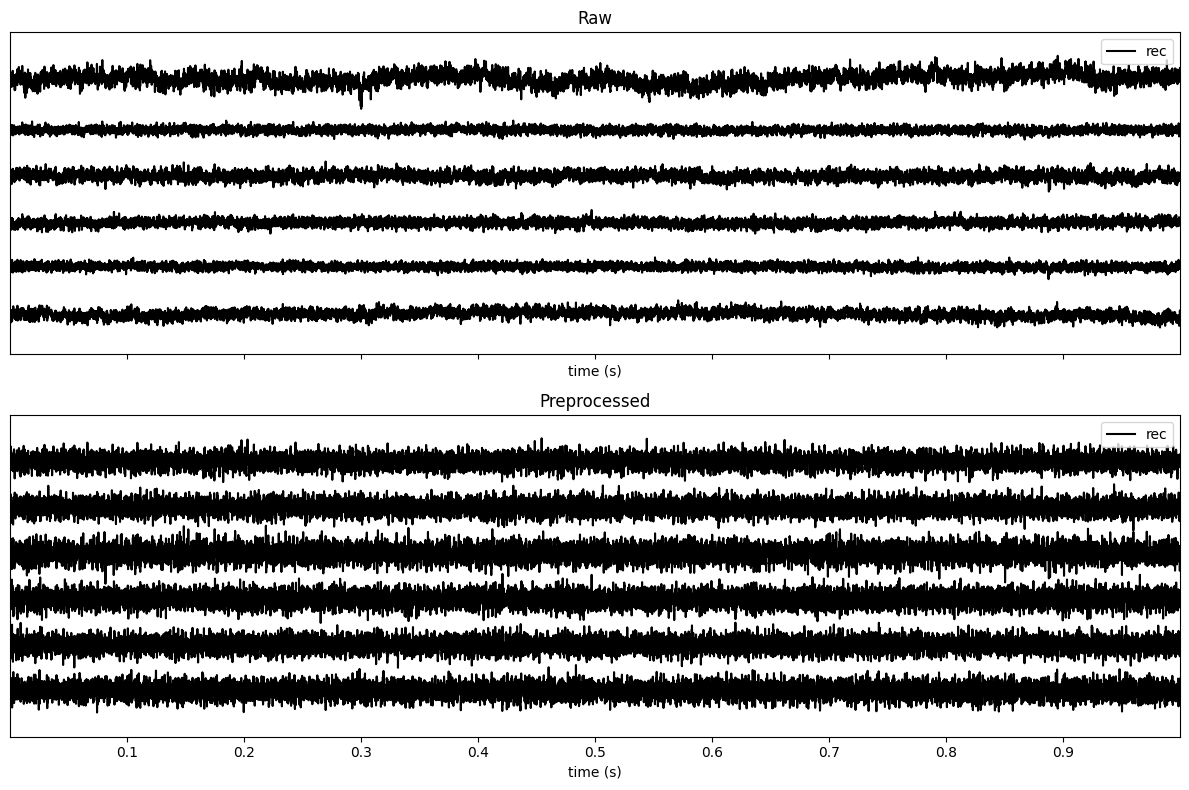

In [7]:
# TRACES VISUALIZATION
import re
_fs    = raw_rec.get_sampling_frequency()
raw_2s = raw_rec.frame_slice(0, int(2 * _fs))
rec_2s = rec.frame_slice(0, int(2 * _fs))

_nat_key     = lambda s: [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]
_good_ch_ids = [c for c in sorted(raw_rec.channel_ids, key=_nat_key) if c in set(rec.channel_ids)]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
si.plot_traces(raw_2s, channel_ids=_good_ch_ids[:6], mode='line', backend='matplotlib', ax=axes[0])
si.plot_traces(rec_2s, channel_ids=_good_ch_ids[:6], mode='line', backend='matplotlib', ax=axes[1])
axes[0].set_title('Raw')
axes[1].set_title('Preprocessed')
plt.tight_layout()
plt.show()

In [8]:
# SAVE PREPROCESSED RECORDING
import gc, shutil
try: del analyzer
except NameError: pass
try: del rec_analysis
except NameError: pass
try: del raw_rec
except NameError: pass
try: del rec1
except NameError: pass
try: del rec2
except NameError: pass
try: del rec3
except NameError: pass
gc.collect()

15

In [9]:
# Windows fix I needed to add, otherwise the file got locked out and I kept having an error, not sure if it's actually needed
_pf = base_folder / 'preprocess'
_pf_loaded = False
if _pf.exists():
    try:
        rec = si.load(_pf)
        _pf_loaded = True
        print(f'Loaded existing preprocessed recording (delete {_pf} to force re-saving)')
    except Exception:
        _pf = base_folder / 'preprocess_new'
        shutil.rmtree(_pf, ignore_errors=True)
        print('Existing preprocess folder is locked/corrupt — saving to preprocess_new')
if not _pf_loaded:
    rec = rec.save(folder=_pf, format='binary',
                   overwrite=True, n_jobs=1, chunk_duration='1s', progress_bar=True)
    print(f'Preprocessed recording saved -> {_pf}')

Loaded existing preprocessed recording (delete C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\preprocess to force re-saving)


In [10]:
# SPIKE SORTING
sorting = si.run_sorter(sorter, rec, folder=base_folder / f'{sorter}_output',
                        remove_existing_folder=True, verbose=True)
print(sorting)

Chunk size not set, setting to 540540 samples.
HSDetection: Analysing segment 0, frames from        0 to   540540  (0.0%)
HSDetection: Analysing segment 0, frames from   540540 to  1081080  (11.1%)
HSDetection: Analysing segment 0, frames from  1081080 to  1621620  (22.2%)
HSDetection: Analysing segment 0, frames from  1621620 to  2162160  (33.4%)
HSDetection: Analysing segment 0, frames from  2162160 to  2702700  (44.5%)
HSDetection: Analysing segment 0, frames from  2702700 to  3243240  (55.6%)
HSDetection: Analysing segment 0, frames from  3243240 to  3783780  (66.7%)
HSDetection: Analysing segment 0, frames from  3783780 to  4324320  (77.9%)
HSDetection: Analysing segment 0, frames from  4324320 to  4860000  (89.0%)
writing spikes to C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\herdingspikes_output\sorter_output\HS2_detected.hdf5
Reading spikes from detection
Fitting dimensionality reduction using all spikes...
...projecting...
...done
Clustering...
Clu

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   3 out of  16 | elapsed:   23.2s remaining:  1.7min
[Parallel(n_jobs=16)]: Done  12 out of  16 | elapsed:   24.5s remaining:    8.1s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:   25.3s finished


Number of estimated units: 32
Saving to C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\herdingspikes_output\sorter_output\HS2_sorted.hdf5
# Sampling rate: 24999.999999999996.
herdingspikes run time 53.71s
HerdingspikesSortingExtractor: 32 units - 1 segments - 25.0kHz
  file_path: C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\herdingspikes_output\sorter_output\HS2_sorted.hdf5


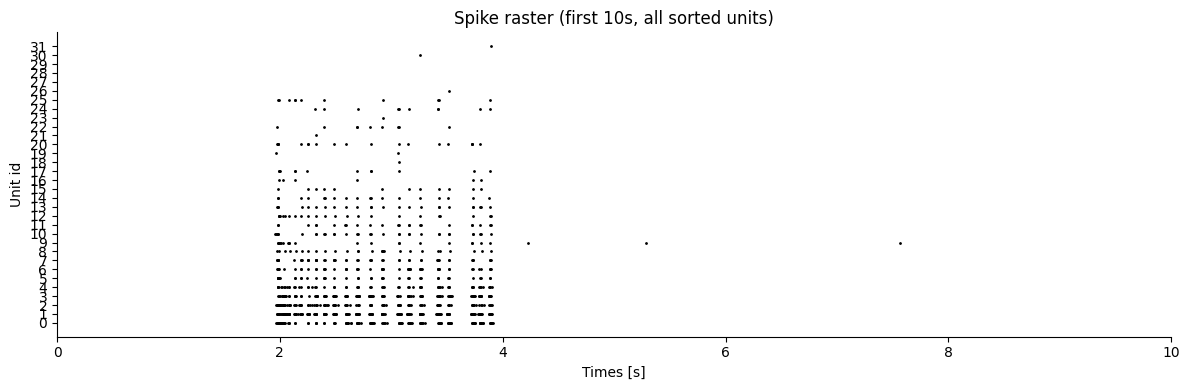

In [11]:
# RASTER PLOT 

#plot is a bit ugly, maybe i can make it better

fig, ax = plt.subplots(figsize=(12, 4))
si.plot_rasters(sorting, time_range=[0, min(10, rec.get_total_duration())], ax=ax)
ax.set_title('Spike raster (first 10s, all sorted units)')
plt.tight_layout()
plt.show()

In [12]:
# SORTING ANALYZER
si.set_global_job_kwargs(n_jobs=1, chunk_duration='1s', progress_bar=True)

rec_analysis = si.load(_pf)

analyzer = si.create_sorting_analyzer(sorting, rec_analysis, sparse=_analyzer_sparse, format='memory')

analyzer.compute('random_spikes', method='uniform', max_spikes_per_unit=max_spikes_per_unit)
analyzer.compute('waveforms', ms_before=waveform_ms_before, ms_after=waveform_ms_after)
analyzer.compute('templates', operators=['average', 'median', 'std'])
analyzer.compute('noise_levels')
analyzer.compute('correlograms')
analyzer.compute('unit_locations')
analyzer.compute('spike_amplitudes')
analyzer.compute('template_similarity')
analyzer.compute('spike_locations')  # required for drift metrics

if compute_pca_metrics:
    analyzer.compute('principal_components', n_components=pca_n_components, mode=pca_mode)

print(analyzer)

compute_waveforms (no parallelization):   0%|          | 0/195 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

spike_amplitudes (no parallelization):   0%|          | 0/195 [00:00<?, ?it/s]

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\postprocessing\template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


spike_locations (no parallelization):   0%|          | 0/195 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/32 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/32 [00:00<?, ?it/s]

SortingAnalyzer: 37 channels - 32 units - 1 segments - memory - has recording
Loaded 10 extensions: random_spikes, waveforms, templates, noise_levels, correlograms, unit_locations, spike_amplitudes, template_similarity, spike_locations, principal_components


In [13]:
# QUALITY METRICS
metrics_ext = analyzer.compute('quality_metrics', metric_names=metric_names,
                               metric_params=metric_extension_params)
metrics     = metrics_ext.get_data()
print(metrics)
metrics.to_csv(base_folder / 'quality_metrics.csv')
print(f"Quality metrics saved -> {base_folder / 'quality_metrics.csv'}")

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\metrics\quality\misc_metrics.py:1026: UserWarning: Amplitude cutoff set to NaN for units [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]: too few spikes (< 500).
  warnings.warn(
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\metrics\quality\misc_metrics.py:1323: Us

    num_spikes  firing_rate  presence_ratio        snr  isi_violations_ratio  \
0         2024    10.411523             1.0  12.235766              3.353435   
1         2448    12.592593             1.0  14.504741              2.519464   
2         1541     7.926955             1.0  10.604654              1.828288   
3         1836     9.444444             1.0  12.532169              2.633602   
4          881     4.531893             1.0  11.526541              0.834878   
5          548     2.818930             1.0   8.099806              4.747190   
6          725     3.729424             1.0   9.557851              3.821736   
7          692     3.559671             1.0  10.553943              6.766013   
8          397     2.042181             1.0   8.941213              2.878008   
9          377     1.939300             1.0   7.454990              1.367772   
10         372     1.913580             1.0   7.902195              5.150884   
11         316     1.625514             

In [14]:
# QUALITY-BASED FILTERING
_conditions = []
if not metrics['amplitude_cutoff'].isna().all():
    _conditions.append(f"(amplitude_cutoff < {amplitude_cutoff_thresh})")
_conditions.append(f"(isi_violations_ratio < {isi_violations_ratio_thresh})")
if not metrics['presence_ratio'].isna().all():
    _conditions.append(f"(presence_ratio > {presence_ratio_thresh})")
query = " & ".join(_conditions)

keep_unit_ids = np.asarray(metrics.query(query).index.tolist(), dtype=sorting.unit_ids.dtype)
print(f"Keeping {len(keep_unit_ids)} / {len(sorting.unit_ids)} units after quality filtering")
if metrics['amplitude_cutoff'].isna().all():
    print("Note: amplitude_cutoff skipped (all NaN, too few spikes per unit)")
if metrics['presence_ratio'].isna().all():
    print("Note: presence_ratio skipped (all NaN, recording shorter than 60s bin)")

analyzer = analyzer.select_units(keep_unit_ids)

Keeping 1 / 32 units after quality filtering


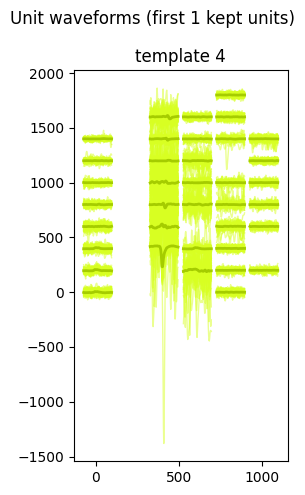

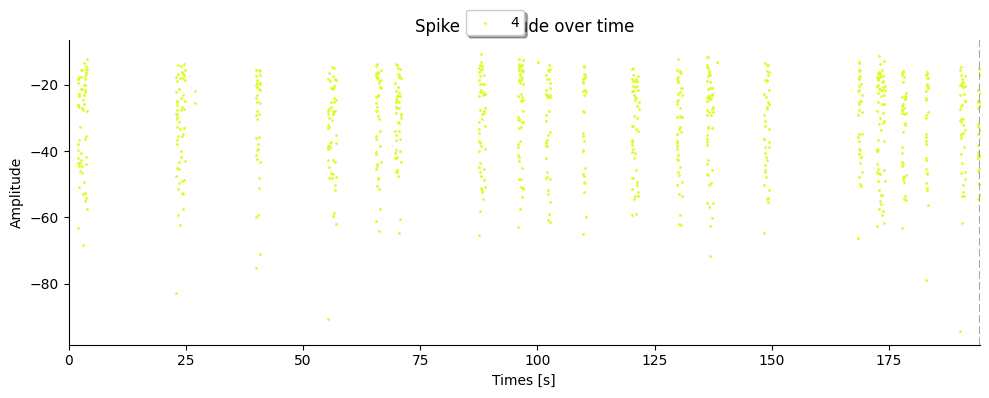

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\widgets\metrics.py:66: UserWarning: Skipping ['amplitude_cv_median', 'amplitude_cv_range'] because they contain all NaNs
  warnings.warn(f"Skipping {nan_metrics} because they contain all NaNs")
C:\Users\labuser\AppData\Local\Temp\ipykernel_2652\3159485404.py:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


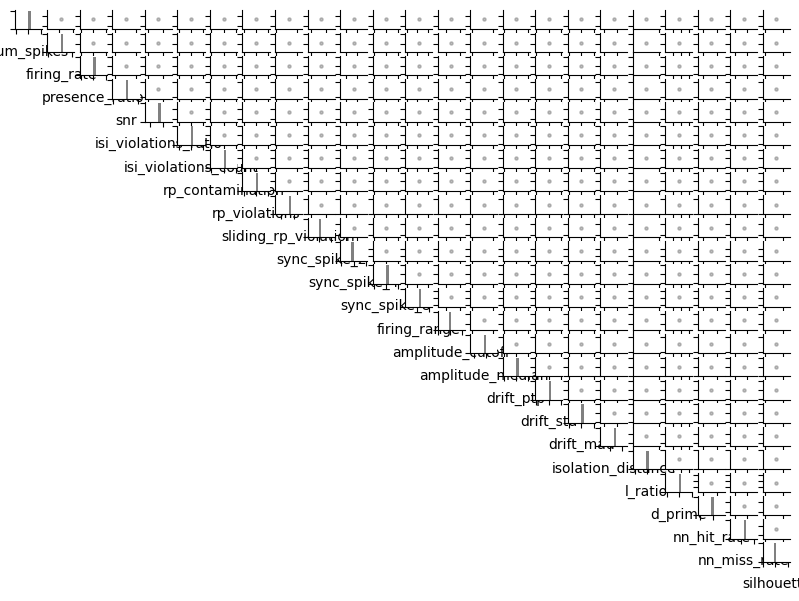

In [15]:
# PER-UNIT DIAGNOSTIC PLOTS 

#needed?? just found on internet

_n_preview = min(6, len(keep_unit_ids))
_preview_units = keep_unit_ids[:_n_preview]

# Waveform shapes — should look like a clean, consistent spike, not pure noise
fig1 = plt.figure(figsize=(3 * _n_preview, 5))
si.plot_unit_waveforms(analyzer, unit_ids=_preview_units, figure=fig1)
plt.suptitle('Unit waveforms (first {} kept units)'.format(_n_preview))
plt.tight_layout()
plt.show()

# Amplitude over time — flat band = stable unit; drifting/declining = possible drift or loss of contact
fig2, ax2 = plt.subplots(figsize=(10, 4))
si.plot_amplitudes(analyzer, unit_ids=_preview_units, ax=ax2)
ax2.set_title('Spike amplitude over time')
plt.tight_layout()
plt.show()

# Quality metric overview — pairwise relationships across all computed metrics
fig3 = plt.figure(figsize=(10, 8))
si.plot_quality_metrics(analyzer, figure=fig3)
plt.tight_layout()
plt.show()


In [16]:
# EXPORT FINAL SPIKE TIMES
_spike_times_folder = base_folder / 'spike_times'
_spike_times_folder.mkdir(exist_ok=True)

_fs_export = rec_analysis.get_sampling_frequency()
for uid in keep_unit_ids:
    _train   = sorting.get_unit_spike_train(uid, segment_index=0)
    _times_s = _train / _fs_export
    np.savetxt(
        _spike_times_folder / f'unit_{uid}.csv',
        _times_s,
        delimiter=',', header='time_s', comments='', fmt='%.6f'
    )
print(f'Spike times for {len(keep_unit_ids)} units -> {_spike_times_folder}')

Spike times for 1 units -> C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\spike_times


In [17]:
# PIPELINE LOG
import json as _json, datetime as _dt

_log = {
    'timestamp':       _dt.datetime.now().isoformat(),
    'si_version':      si.__version__,
    'format':          FORMAT,
    'source_path':     _source_path,
    'sorter':          sorter,
    'n_channels_raw':  int(_n_raw_channels),
    'n_channels_kept': int(rec_analysis.get_num_channels()),
    'bad_channel_ids': [str(c) for c in bad_channel_ids],
    'n_units_sorted':  int(len(sorting.unit_ids)),
    'n_units_kept':    int(len(keep_unit_ids)),
    'parameters': {
        'freq_min':                    freq_min,
        'cref_operator':               cref_operator,
        'cref_reference':              cref_reference,
        'waveform_ms_before':          waveform_ms_before,
        'waveform_ms_after':           waveform_ms_after,
        'max_spikes_per_unit':         max_spikes_per_unit,
        'amplitude_cutoff_thresh':     amplitude_cutoff_thresh,
        'isi_violations_ratio_thresh': isi_violations_ratio_thresh,
        'presence_ratio_thresh':       presence_ratio_thresh,
    },
}
_log_path = base_folder / 'pipeline_run_log.json'
_log_path.write_text(_json.dumps(_log, indent=2))
print(f'Run log -> {_log_path}')

Run log -> C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\pipeline_run_log.json


In [18]:
# SAVE ANALYZER
import shutil
_analyzer_folder = base_folder / 'analyzer'
if _analyzer_folder.exists():
    shutil.rmtree(_analyzer_folder)
analyzer.save_as(folder=_analyzer_folder, format='binary_folder')

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\core\basesorting.py:384: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


SortingAnalyzer: 37 channels - 1 units - 1 segments - binary_folder - has recording
Loaded 11 extensions: random_spikes, waveforms, templates, noise_levels, correlograms, unit_locations, spike_amplitudes, template_similarity, spike_locations, principal_components, quality_metrics

In [19]:
# INTERACTIVE VIEWER (sigui)

import spikeinterface_gui
spikeinterface_gui.run_mainwindow(analyzer)